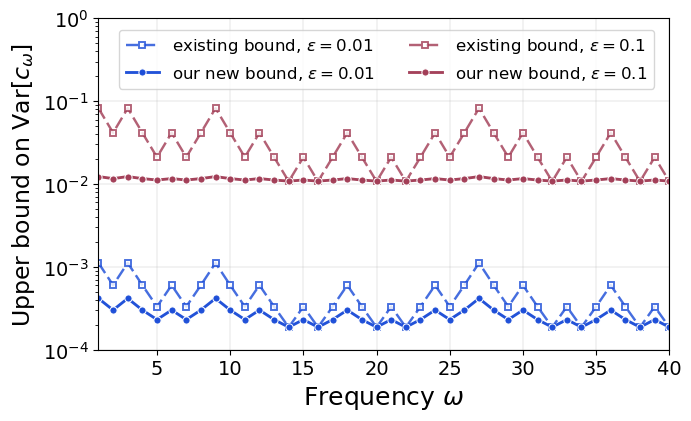

saved to /Users/letao/DataSpellProjects/Fourier-symmetrization/figures/operator_norm_bound_manual_comparison.png


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

MANUAL_EPSILONS_OP = (0.01, 0.1)
MANUAL_OUTPUT_PATH = Path("figures/operator_norm_bound_manual_comparison.png")
MANUAL_N_QUBITS = 4
MANUAL_D = 2 ** MANUAL_N_QUBITS


def manual_weighted_encoding_redundancies(betas):
    counts = {0: 1}
    for beta in betas:
        beta = int(beta)
        next_counts = {}
        for freq, multiplicity in counts.items():
            for delta, delta_mult in ((-beta, 1), (0, 2), (beta, 1)):
                next_counts[freq + delta] = next_counts.get(freq + delta, 0) + multiplicity * delta_mult
        counts = next_counts
    freqs = np.array(sorted(freq for freq in counts if freq > 0), dtype=int)
    redundancies = np.array([counts[int(freq)] for freq in freqs], dtype=float)
    return freqs, redundancies


def manual_theorem5_global_projector_variance(redundancies, d):
    # For nonzero frequencies and O=|0><0|, the delta term in Theorem 5 is absent.
    trace_o = 1.0
    norm2_sq = 1.0
    return (
            (d * norm2_sq - trace_o**2)
            / (d * (d**2 - 1))
            * redundancies
            / (d * (d + 1))
    )


def existing_spectral_bound(var_2design, redundancies, d, epsilon_op):
    # Existing spectral-norm version of Theorem 7, using epsilon_infty = epsilon_op.
    trace_o = 1.0
    norm2_sq = 1.0
    c1 = (d * norm2_sq - trace_o**2) / (d * (d**2 - 1))
    return (
            var_2design
            + (c1 + norm2_sq / (d * (d + 1))) * epsilon_op * np.sqrt(redundancies)
            + norm2_sq * epsilon_op**2 * redundancies
    )


def our_corollary9_bound(var_2design, redundancies, d, epsilon_op):
    # Corollary 9 aggregated-coefficient bound for O=|0><0|.
    trace_o = 1.0
    frobenius_norm_sq = 1.0
    leading_prefactor = ((2 * d - 1) * frobenius_norm_sq - trace_o**2) / (d * (d**2 - 1))
    return (
            var_2design
            + epsilon_op * np.sqrt(redundancies) * leading_prefactor
            + (epsilon_op**2 + epsilon_op**4) * frobenius_norm_sq
    )


ENCODING_NAME = ""
ENCODING_BETAS = 3 ** np.arange(MANUAL_N_QUBITS)

epsilon_colors = ["#1D4ED8", "#A23E57", "#16A34A", "#DC2626", "#7C3AED", "#0891B2"]

def line_style(bound_type, epsilon_index):
    # Works for any manually chosen epsilon values; colors cycle if more than six are used.
    color = epsilon_colors[epsilon_index % len(epsilon_colors)]
    if bound_type == "existing":
        return dict(color=color, linestyle=(0, (5, 2)), marker="s", markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.35, alpha=0.82)
    if bound_type == "ours":
        return dict(color=color, linestyle="-", marker="o", markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.75, alpha=0.98)
    raise ValueError(bound_type)

fig, ax = plt.subplots(1, 1, figsize=(6.8, 4.1), constrained_layout=True)

freqs, redundancies = manual_weighted_encoding_redundancies(ENCODING_BETAS)
var_2design = manual_theorem5_global_projector_variance(redundancies, MANUAL_D)

visible_values = []
for epsilon_index, epsilon_op in enumerate(MANUAL_EPSILONS_OP):
    existing = existing_spectral_bound(var_2design, redundancies, MANUAL_D, epsilon_op)
    ours = our_corollary9_bound(var_2design, redundancies, MANUAL_D, epsilon_op)
    visible_values.extend([existing, ours])

    ax.plot(
        freqs,
        existing,
        label=rf"existing bound, $\epsilon={epsilon_op}$",
        markersize=5.0,
        linewidth=1.75,
        **line_style("existing", epsilon_index),
    )
    ax.plot(
        freqs,
        ours,
        label=rf"our new bound, $\epsilon={epsilon_op}$",
        markersize=5.2,
        linewidth=2.05,
        **line_style("ours", epsilon_index),
    )

y_values = np.concatenate(visible_values)
y_values = y_values[np.isfinite(y_values) & (y_values > 0)]
y_min = 10 ** np.floor(np.log10(np.min(y_values)) - 0.15)
y_max = 10 ** np.ceil(np.log10(np.max(y_values)) + 0.45)
# y_max = max(10.0, 10 ** np.ceil(np.log10(np.max(y_values)) + 0.45))


ax.set_title(ENCODING_NAME, fontsize=25, pad=15)
ax.set_yscale("log")
ax.set_ylim(y_min, y_max)
ax.set_xlim(left=1, right=int(freqs[-1]))
ax.set_xlabel(r"Frequency $\omega$", fontsize=18)
ax.set_ylabel(r"Upper bound on $\mathrm{Var}[c_\omega]$", fontsize=17)
ax.grid(linewidth=0.35, alpha=0.65)
ax.tick_params(axis="both", which="major", labelsize=14)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.56, 0.96), ncol=2, fontsize=12, frameon=True)
fig.savefig(MANUAL_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved to {MANUAL_OUTPUT_PATH.resolve()}")